In [55]:
from sklearn import datasets
import numpy as np
import matplotlib.pyplot as plt


iris = datasets.load_iris()
x = iris["data"][: , (2 , 3)]
y = iris["target"]
print(x.shape)

setosa_or_versicolor = (y==0) | (y == 1)
x = x[setosa_or_versicolor]
y = y[setosa_or_versicolor]


(150, 2)


In [56]:
x.shape

(100, 2)

In [57]:
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import SGDClassifier


C_1 = 5
m = len(x)
alpha = 1 / m * C_1

linear_svc = LinearSVC(C = C_1 , loss= "hinge")
svc = SVC(kernel="linear",C= C_1)
sgd_classifier = SGDClassifier(loss="hinge",alpha= alpha)

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)


In [58]:
linear_svc.fit(x_scaled , y)
svc.fit(x_scaled , y)
sgd_classifier.fit(x_scaled , y)

SGDClassifier(alpha=0.05)

In [59]:
print(linear_svc.coef_ , linear_svc.intercept_)
print(svc.coef_ , svc.intercept_)
print(sgd_classifier.coef_ ,sgd_classifier.intercept_)

[[1.05364598 1.09903627]] [0.28475221]
[[1.1203284  1.02625193]] [0.31896852]
[[0.87267498 0.81071344]] [0.31428609]


In [60]:
w1 = -linear_svc.coef_[0 , 0] / linear_svc.coef_[0 , 1]
b1 = -linear_svc.intercept_[0]/ linear_svc.coef_[0 , 1]
w2 = -svc.coef_[0 , 0] / svc.coef_[0 , 1]
b2 = -svc.intercept_[0] / svc.coef_[0 , 1]
w3 = -sgd_classifier.coef_[0 , 0] / sgd_classifier.coef_[0 , 1]
b3 = -sgd_classifier.intercept_[0] / sgd_classifier.coef_[0 , 1]

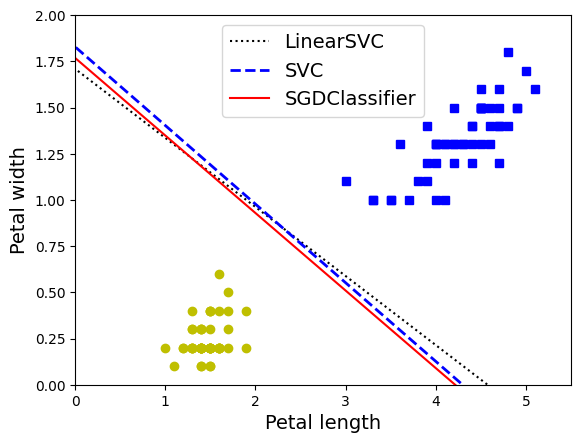

In [66]:
line1 = scaler.inverse_transform([[-10, -10*w1 + b1], [10, 10*w1 + b1]])
line2 = scaler.inverse_transform([[-10, -10*w2 + b2], [10, 10*w2 + b2]])
line3 = scaler.inverse_transform([[-10, -10*w3 + b3], [10, 10*w3 + b3]])

plt.plot(line1[:, 0], line1[:, 1], "k:", label="LinearSVC")
plt.plot(line2[:, 0], line2[:, 1], "b--", linewidth=2, label="SVC")
plt.plot(line3[:, 0], line3[:, 1], "r-", label="SGDClassifier")
plt.plot(x[:, 0][y==1], x[:, 1][y==1], "bs") # label="Iris-Versicolor"
plt.plot(x[:, 0][y==0], x[:, 1][y==0], "yo") # label="Iris-Setosa"
plt.xlabel("Petal length", fontsize=14)
plt.ylabel("Petal width", fontsize=14)
plt.legend(loc="upper center", fontsize=14)
plt.axis([0, 5.5, 0, 2])

plt.show()